In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.style.use('default')

np.random.seed(2137)

def save_simple_tex(df, filename, caption, label):
    df_out = df.copy()
    
    def fmt(x):
        if isinstance(x, (float, np.floating)):
            return "{:.4f}".format(x)
        return x
    
    df_out = df_out.applymap(fmt)
    
    new_cols = [c.replace("Empiryczne", "Emp").replace("Teoretyczne", "Theo")
                 .replace("Rozkład", "Dist").replace("Różnica", "Diff") 
                 for c in df_out.columns]
    df_out.columns = new_cols

    df_out.to_latex(
        filename, index=False, caption=caption, label=label,
        position="H", column_format="l" + "c"*len(df_out.columns), escape=False
    )
    print(f"[OK] Zapisano: {filename}")

n = 200
std_dev_x = np.sqrt(1/500)
X = np.random.normal(0, std_dev_x, n)

X_mean = np.mean(X)
Sxx = np.sum((X - X_mean)**2)

print(f"X wygenerowane. Sxx = {Sxx:.4f}")

X wygenerowane. Sxx = 0.4162


In [2]:
scenarios = [
    # a, b, c -> Beta1 = 0 (Badamy Błąd I Rodzaju / Alpha)
    {"id": "a", "beta1": 0, "dist": "Normal",   "func": lambda n: np.random.normal(0, 1, n), "var": 1.0},
    {"id": "b", "beta1": 0, "dist": "Exp(1) - 1",   "func": lambda n: np.random.exponential(1, n) - 1, "var": 1.0},
    {"id": "c", "beta1": 0, "dist": "Logistic", "func": lambda n: np.random.logistic(0, 1, n), "var": (np.pi**2)/3},
    
    # d, e, f -> Beta1 = 2 (Badamy Moc Testu)
    {"id": "d", "beta1": 2, "dist": "Normal",   "func": lambda n: np.random.normal(0, 1, n), "var": 1.0},
    {"id": "e", "beta1": 2, "dist": "Exp(1) - 1",   "func": lambda n: np.random.exponential(1, n) - 1, "var": 1.0},
    {"id": "f", "beta1": 2, "dist": "Logistic", "func": lambda n: np.random.logistic(0, 1, n), "var": (np.pi**2)/3},
]

def calculate_theoretical_power(beta1, var_epsilon, Sxx, n, alpha=0.05):
    """
    Oblicza teoretyczną moc testu. 
    Dla beta1=0 zwraca poziom istotności alpha.
    """
    if beta1 == 0:
        return alpha
    
    # Parametr niecentralności (delta)
    sigma = np.sqrt(var_epsilon)
    se_b1 = sigma / np.sqrt(Sxx)
    delta = beta1 / se_b1
    
    # Moc z rozkładu niecentralnego t
    df = n - 2
    t_crit = stats.t.ppf(1 - alpha/2, df)
    power = 1 - stats.nct.cdf(t_crit, df, delta) + stats.nct.cdf(-t_crit, df, delta)
    return power

In [3]:
results = []
repeats = 1000
alpha = 0.05

for scen in scenarios:
    rejections = 0
    
    # Obliczamy teoretyczną wartość (Alpha lub Moc)
    theo_val = calculate_theoretical_power(scen['beta1'], scen['var'], Sxx, n, alpha)
    
    for _ in range(repeats):
        epsilon = scen['func'](n)
        Y = 5 + scen['beta1'] * X + epsilon
        
        # Szybka regresja (liczymy tylko p-value dla slope)
        res = stats.linregress(X, Y)
        if res.pvalue < alpha:
            rejections += 1
            
    emp_rate = rejections / repeats
    
    results.append({
        "ID": f"({scen['id']})",
        "Beta1": scen['beta1'],
        "Rozkład": scen['dist'],
        "Empiryczne": emp_rate,
        "Teoretyczne": theo_val,
        "Różnica": emp_rate - theo_val
    })

df_mc = pd.DataFrame(results)

save_simple_tex(df_mc, 'zad3_monte_carlo.tex', 'Wyniki symulacji (1000 powtórzeń)', 'tab:zad3_mc')
display(df_mc)

[OK] Zapisano: zad3_monte_carlo.tex


/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_8236/1482377288.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_out = df_out.applymap(fmt)


,ID,Beta1,Rozkład,Empiryczne,Teoretyczne,Różnica
0,(a),0,Normal,0.044,0.050000,-0.006000
1,(b),0,Exp(1) - 1,0.047,0.050000,-0.003000
2,(c),0,Logistic,0.040,0.050000,-0.010000
3,(d),2,Normal,0.246,0.250128,-0.004128
4,(e),2,Exp(1) - 1,0.253,0.250128,0.002872
5,(f),2,Logistic,0.105,0.109094,-0.004094


[OK] Zapisano wykres.


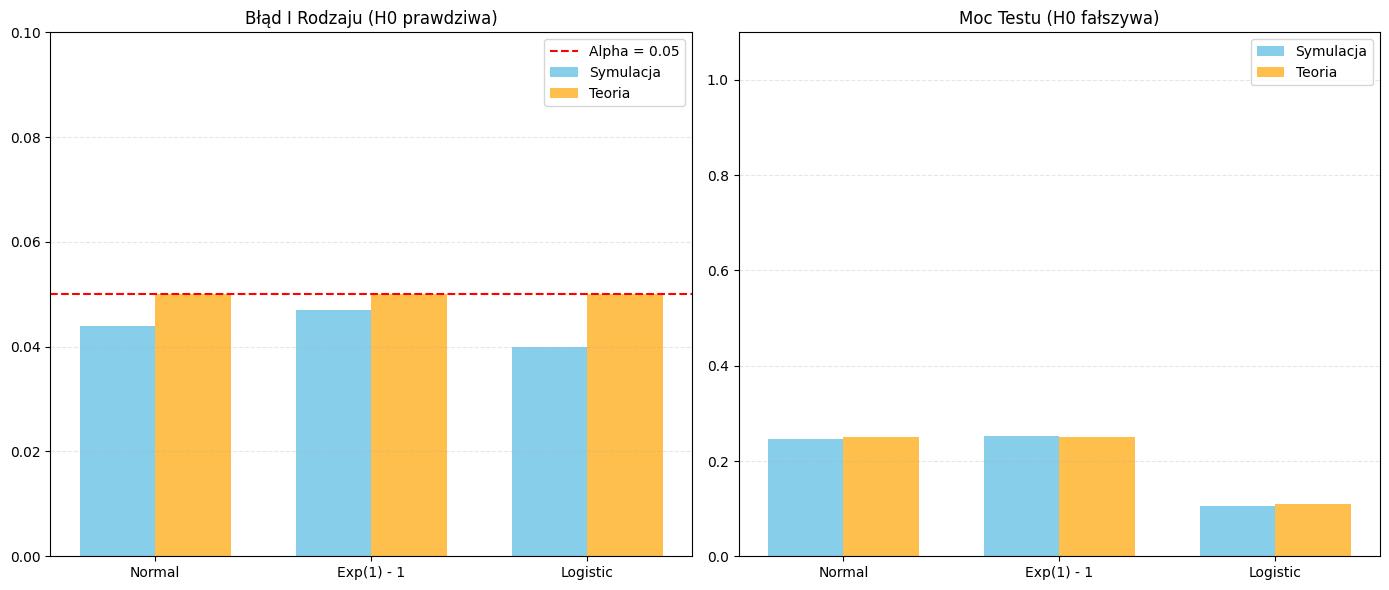

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Błąd I rodzaju (Beta = 0)
df_type1 = df_mc[df_mc['Beta1'] == 0]
x = np.arange(len(df_type1))
width = 0.35

ax[0].bar(x - width/2, df_type1['Empiryczne'], width, label='Symulacja', color='skyblue')
ax[0].bar(x + width/2, df_type1['Teoretyczne'], width, label='Teoria', color='orange', alpha=0.7)
ax[0].axhline(0.05, color='red', linestyle='--', label='Alpha = 0.05')

ax[0].set_title('Błąd I Rodzaju (H0 prawdziwa)')
ax[0].set_xticks(x)
ax[0].set_xticklabels(df_type1['Rozkład'])
ax[0].set_ylim(0, 0.1)
ax[0].legend()
ax[0].grid(axis='y', linestyle='--', alpha=0.3)

# 2. Moc Testu (Beta = 2)
df_power = df_mc[df_mc['Beta1'] == 2]
x = np.arange(len(df_power))

ax[1].bar(x - width/2, df_power['Empiryczne'], width, label='Symulacja', color='skyblue')
ax[1].bar(x + width/2, df_power['Teoretyczne'], width, label='Teoria', color='orange', alpha=0.7)

ax[1].set_title('Moc Testu (H0 fałszywa)')
ax[1].set_xticks(x)
ax[1].set_xticklabels(df_power['Rozkład'])
ax[1].set_ylim(0, 1.1)
ax[1].legend()
ax[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('zad3_wykres.png')
print("[OK] Zapisano wykres.")
plt.show()